# LangGraph Workshop

## Building Predictable, Controllable AI Agents with Graph-Based Workflows

This notebook covers:

**PART 1: From Agents to Graphs**
- Why Traditional Agents Break
- LangGraph Mental Model: Nodes, Edges, State
- Your First LangGraph Workflow

**PART 2: State, Control Flow, and Reliability**
- Typed State Objects
- Conditional Edges
- Loops and Retries

**PART 3: Building Real Agent Workflows**
- Adding LLMs and Tools
- Human-in-the-Loop Patterns
- Memory in Graphs

**PART 4: LangGraph vs LangChain Agents Comparison**

---

# PART 1: From Agents to Graphs

---

## Section 1.1: Setup & Configuration

In [1]:
# Install required dependencies
!pip install -q \
    langgraph>=0.2.0 \
    langchain>=0.3.0 \
    langchain-openai>=0.2.0 \
    langchain-community>=0.3.0 \
    langchain-core>=0.3.0 \
    python-dotenv>=1.0 \
    requests>=2.31.0 \
    pydantic>=2.0

zsh:1: 0.2.0 not found


In [8]:
import os
from dotenv import load_dotenv

# Load environment variables
for p in [".env", "agents/.env", os.path.join(os.getcwd(), ".env")]:
    if os.path.exists(p):
        load_dotenv(p)
        break
load_dotenv()

# Configuration
USE_OPENROUTER = True  # Set to False for direct OpenAI

if USE_OPENROUTER:
    API_KEY = os.getenv("OPENROUTER_API_KEY", "your-openrouter-api-key")
    BASE_URL = "https://openrouter.ai/api/v1"
    MODEL_NAME = "openai/gpt-4o-mini"
    print("Using OpenRouter API")
else:
    API_KEY = os.getenv("OPENAI_API_KEY", "your-openai-api-key")
    BASE_URL = None
    MODEL_NAME = "gpt-4o-mini"
    print("Using OpenAI API directly")

print("Configuration loaded successfully!")

Using OpenRouter API
Configuration loaded successfully!


In [9]:
from langchain_openai import ChatOpenAI

# Initialize the LLM
llm = ChatOpenAI(
    model=MODEL_NAME,
    openai_api_key=API_KEY,
    openai_api_base=BASE_URL,
    temperature=0,
    max_tokens=1000,
)

# Test connection
response = llm.invoke("Say 'Hello, LangGraph!' in a creative way.")
print(response.content)

Greetings, magnificent tapestry of language and thought, LangGraph! 🌟✨


## Python Dictinary 

In [1]:
class_name={"name":"Rahul", "age":25}

In [3]:
class_name["age"]= "Twentyfive"

In [4]:
class_name

{'name': 'Rahul', 'age': 'Twentyfive'}

In [5]:
class_name["rollno"]=45

In [6]:
class_name

{'name': 'Rahul', 'age': 'Twentyfive', 'rollno': 45}

## Section 1.2: Why Traditional Agents Break

In the previous session, we built LangChain agents using `AgentExecutor`. While powerful, they have limitations:

| Problem | Description |
|---------|-------------|
| **Hard to predict** | LLM decides everything - you can't control the path |
| **Limited state control** | Only scratchpad, no custom state tracking |
| **Tough to debug** | Agent reasoning is opaque |
| **Only linear chains** | Can't easily branch, retry, or recover |

Let's see the problem in action:

In [10]:
# Quick recap: A LangChain agent (from last session)
from langchain_core.tools import tool
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_classic.agents import AgentExecutor, create_tool_calling_agent

@tool
def search_database(query: str) -> str:
    """Search the database for information."""
    # Simulate sometimes failing
    import random
    if random.random() < 0.3:
        return "Error: Database connection timeout"
    return f"Found results for: {query}"

tools = [search_database]

prompt = ChatPromptTemplate.from_messages([
    ("system", "You are a helpful assistant."),
    ("human", "{input}"),
    MessagesPlaceholder(variable_name="agent_scratchpad")
])

agent = create_tool_calling_agent(llm, tools, prompt)
executor = AgentExecutor(agent=agent, tools=tools, verbose=True, max_iterations=3)

# Run it - notice we can't control retry logic!
result = executor.invoke({"input": "Search for Python tutorials"})
print(f"\nResult: {result['output']}")



> Entering new AgentExecutor chain...

Invoking: `search_database` with `{'query': 'Python tutorials'}`


Found results for: Python tutorialsI found some results for Python tutorials. Would you like a summary or specific details about any of them?

> Finished chain.

Result: I found some results for Python tutorials. Would you like a summary or specific details about any of them?


### The Core Problem

With traditional agents:
- If the database fails, the agent might give up or retry unpredictably
- We can't inject custom logic (e.g., "try 3 times, then use fallback")
- We can't pause for human approval
- State is hidden in the scratchpad

**LangGraph solves this by letting us think in graphs, not loops.**

## Section 1.3: The LangGraph Mental Model

LangGraph represents workflows as directed graphs:

```
┌─────────────────────────────────────────────────────────────┐
│                                                             │
│   NODES = Steps (functions)                                 │
│   - LLM calls                                               │
│   - Tool execution                                          │
│   - Validation                                              │
│   - Any Python function                                     │
│                                                             │
│   EDGES = Transitions                                       │
│   - Success → next step                                     │
│   - Failure → fallback                                      │
│   - Conditional → branch based on state                     │
│                                                             │
│   STATE = Shared memory                                     │
│   - Typed dictionary                                        │
│   - Passed to every node                                    │
│   - Nodes return updates                                    │
│                                                             │
└─────────────────────────────────────────────────────────────┘
```

**Key Insight**: Instead of the LLM deciding everything, YOU define the graph structure!

## Section 1.4: Your First LangGraph - Simple Q&A

Let's build a minimal graph with:
- 2 nodes: `input_node` and `answer_node`
- Simple state: `question` and `answer`

In [11]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END

# Step 1: Define the State
# This is a typed dictionary that carries data through the graph
class QAState(TypedDict):
    question: str
    answer: str

print("State schema defined!")
print(f"Fields: question (str), answer (str)")

State schema defined!
Fields: question (str), answer (str)


In [12]:
# Step 2: Define the Nodes (functions that process state)

def input_node(state: QAState) -> dict:
    """
    First node: Receives the question.
    In a real app, this might validate or preprocess.
    """
    print(f"[INPUT NODE] Received question: {state['question']}")
    # Return empty dict - no state updates needed
    return {}

def answer_node(state: QAState) -> dict:
    """
    Second node: Uses LLM to answer the question.
    Returns an update to the 'answer' field.
    """
    print(f"[ANSWER NODE] Generating answer...")
    response = llm.invoke(state["question"])
    return {"answer": response.content}

print("Nodes defined!")

Nodes defined!


In [13]:
# Step 3: Build the Graph

# Create a graph builder with our state type
graph_builder = StateGraph(QAState)

# Add nodes
graph_builder.add_node("input_node", input_node)
graph_builder.add_node("answer_node", answer_node)

# Add edges (define the flow)
graph_builder.add_edge(START, "input_node")        # Start -> input_node
graph_builder.add_edge("input_node", "answer_node") # input_node -> answer_node
graph_builder.add_edge("answer_node", END)         # answer_node -> End

# Compile the graph
qa_graph = graph_builder.compile()

print("Graph compiled!")
print("Flow: START -> input_node -> answer_node -> END")

Graph compiled!
Flow: START -> input_node -> answer_node -> END


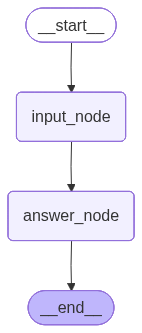

In [14]:
# Step 4: Visualize the graph (optional but helpful!)
from IPython.display import Image, display

try:
    display(Image(qa_graph.get_graph().draw_mermaid_png()))
except Exception as e:
    print(f"Visualization requires additional dependencies: {e}")
    print("\nGraph structure:")
    print("START -> input_node -> answer_node -> END")

In [15]:
# Step 5: Run the graph!

result = qa_graph.invoke({"question": "What is the capital of France?", "answer": ""})

print("\n" + "="*60)
print("FINAL STATE:")
print(f"Question: {result['question']}")
print(f"Answer: {result['answer']}")

[INPUT NODE] Received question: What is the capital of France?
[ANSWER NODE] Generating answer...

FINAL STATE:
Question: What is the capital of France?
Answer: The capital of France is Paris.


### What Just Happened?

1. We created initial state: `{"question": "...", "answer": ""}`
2. Graph started at `START`, moved to `input_node`
3. `input_node` received state, returned `{}` (no changes)
4. Graph moved to `answer_node`
5. `answer_node` called LLM, returned `{"answer": "..."}`
6. State was updated with the answer
7. Graph moved to `END`

**Key Difference from Agents**: We explicitly defined every step!

---

# PART 2: State, Control Flow, and Reliability

---

## Section 2.1: Typed State Objects

State is the backbone of LangGraph. Let's explore more complex state:

In [11]:
from typing import TypedDict, List, Optional, Annotated
from operator import add

# More complex state for a research assistant
class ResearchState(TypedDict):
    # User's question
    question: str
    
    # Search results (list that accumulates)
    search_results: Annotated[List[str], add]  # <-- Using reducer!
    
    # Context for the LLM
    context: str
    
    # Final answer
    answer: str
    
    # Control flags
    has_enough_context: bool
    attempts: int

print("State with typed fields and reducers!")
print("\nAnnotated[List[str], add] means:")
print("  - Multiple nodes can add to search_results")
print("  - Results accumulate instead of replacing")

State with typed fields and reducers!

Annotated[List[str], add] means:
  - Multiple nodes can add to search_results
  - Results accumulate instead of replacing


### State Reducers

By default, when a node returns `{"field": value}`, it **replaces** the field.

With `Annotated[List[str], add]`, the value is **appended** instead.

```python
# Without reducer:
state = {"results": ["a"]}
update = {"results": ["b"]}
# Final: {"results": ["b"]}  <-- Replaced!

# With Annotated[List[str], add]:
state = {"results": ["a"]}
update = {"results": ["b"]}
# Final: {"results": ["a", "b"]}  <-- Accumulated!
```

## Section 2.2: Conditional Edges

The real power of LangGraph: branching based on state!

In [ ]:
# Let's build a graph with conditional routing

class ValidationState(TypedDict):
    input_text: str
    is_valid: bool
    error_message: str.     ##typed dict memory 
    processed_result: str



## Nodes definition

def validate_input(state: ValidationState) -> dict:
    """Validate the input text."""
    text = state["input_text"]
    print(f"[VALIDATE] Checking: '{text}'")
    
    if len(text) < 3:
        return {
            "is_valid": False,
            "error_message": "Input too short (min 3 characters)"
        }
    elif not text.replace(" ", "").isalnum():
        return {
            "is_valid": False,
            "error_message": "Input contains special characters"
        }
    else:
        return {"is_valid": True, "error_message": ""}

def process_valid(state: ValidationState) -> dict:
    """Process valid input."""
    print(f"[PROCESS] Processing valid input...")
    result = f"Processed: {state['input_text'].upper()}"
    return {"processed_result": result}
    

def handle_error(state: ValidationState) -> dict:
    """Handle invalid input."""
    print(f"[ERROR] Handling error: {state['error_message']}")
    return {"processed_result": f"ERROR: {state['error_message']}"}

print("Nodes defined!")

Nodes defined!


In [19]:
# Define the routing function
def route_after_validation(state: ValidationState) -> str:
    """
    Conditional routing function.
    Returns the name of the next node to visit.
    """
    if state["is_valid"]:
        return "process_valid"
    else:
        return "handle_error"

print("Routing function defined!")

Routing function defined!


In [20]:
# Build the conditional graph

validation_graph = StateGraph(ValidationState)

# Add nodes
validation_graph.add_node("validate", validate_input)
validation_graph.add_node("process_valid", process_valid)
validation_graph.add_node("handle_error", handle_error)

# Add edges
validation_graph.add_edge(START, "validate")

# Add CONDITIONAL edge - this is the key!
validation_graph.add_conditional_edges(
    "validate",  # Source node
    route_after_validation,  # Routing function
    {  # Mapping of return values to node names
        "process_valid": "process_valid",
        "handle_error": "handle_error"
    }
)

# Both branches lead to END
validation_graph.add_edge("process_valid", END)
validation_graph.add_edge("handle_error", END)

# Compile
validation_app = validation_graph.compile()

print("Conditional graph compiled!")

Conditional graph compiled!


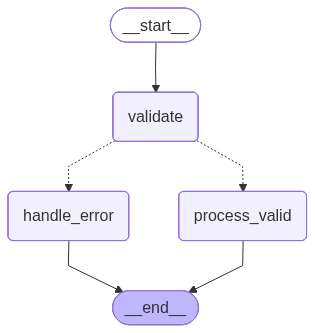

In [21]:
# Visualize
try:
    display(Image(validation_app.get_graph().draw_mermaid_png()))
except:
    print("Graph structure:")
    print("START -> validate -> [conditional] -> process_valid OR handle_error -> END")

In [23]:
# Test with valid input
print("="*60)
print("TEST 1: Valid input")
print("="*60)

result = validation_app.invoke({
    "input_text": "He",
    "is_valid": False,
    "error_message": "",
    "processed_result": ""
})

print(f"\nResult: {result['processed_result']}")

TEST 1: Valid input
[VALIDATE] Checking: 'He'
[ERROR] Handling error: Input too short (min 3 characters)

Result: ERROR: Input too short (min 3 characters)


In [21]:
# Test with invalid input
print("="*60)
print("TEST 2: Invalid input (too short)")
print("="*60)

result = validation_app.invoke({
    "input_text": "Hello world ",
    "is_valid": False,
    "error_message": "",
    "processed_result": ""
})

print(f"\nResult: {result['processed_result']}")

TEST 2: Invalid input (too short)
[VALIDATE] Checking: 'Hello world '
[PROCESS] Processing valid input...

Result: Processed: HELLO WORLD 


## Section 2.3: Loops and Retries

LangGraph supports cycles! Let's build a retry loop:

In [24]:
import random

class RetryState(TypedDict):
    query: str
    results: str
    attempts: int
    max_attempts: int
    success: bool

def search_node(state: RetryState) -> dict:
    """Simulates a search that sometimes fails."""
    attempts = state["attempts"] + 1
    print(f"[SEARCH] Attempt {attempts}/{state['max_attempts']}")
    
    # Simulate 50% failure rate
    if random.random() < 0.5:
        print("  -> Failed!")
        return {"attempts": attempts, "success": False, "results": ""}
    else:
        print("  -> Success!")
        return {
            "attempts": attempts,
            "success": True,
            "results": f"Results for '{state['query']}': [data, data, data]"
        }

def evaluate_results(state: RetryState) -> dict:
    """Evaluate if we have good results."""
    print(f"[EVALUATE] Success: {state['success']}, Attempts: {state['attempts']}")
    return {}

def format_results(state: RetryState) -> dict:
    """Format successful results."""
    print(f"[FORMAT] Formatting results...")
    return {"results": f"Formatted: {state['results']}"}

def fallback_node(state: RetryState) -> dict:
    """Fallback when all retries fail."""
    print(f"[FALLBACK] All {state['attempts']} attempts failed.")
    return {"results": "No results found after maximum retries."}

In [25]:
def decide_after_evaluate(state: RetryState) -> str:
    """
    Decide next step after evaluation:
    - Success -> format
    - Failed but attempts remaining -> retry (loop back)
    - Failed and max attempts -> fallback
    """
    if state["success"]:
        return "format"
    elif state["attempts"] < state["max_attempts"]:
        return "retry"  # Loop back to search!
    else:
        return "fallback"

print("Routing function with retry logic defined!")

Routing function with retry logic defined!


In [26]:
# Build the retry graph

retry_graph = StateGraph(RetryState)

# Add nodes
retry_graph.add_node("search", search_node)
retry_graph.add_node("evaluate", evaluate_results)
retry_graph.add_node("format", format_results)
retry_graph.add_node("fallback", fallback_node)

# Add edges
retry_graph.add_edge(START, "search")
retry_graph.add_edge("search", "evaluate")

# Conditional edges with LOOP
retry_graph.add_conditional_edges(
    "evaluate",
    decide_after_evaluate,
    {
        "format": "format",
        "retry": "search",  # Loop back to search!
        "fallback": "fallback"
    }
)

retry_graph.add_edge("format", END)
retry_graph.add_edge("fallback", END)

retry_app = retry_graph.compile()

print("Retry graph with cycle compiled!")

Retry graph with cycle compiled!


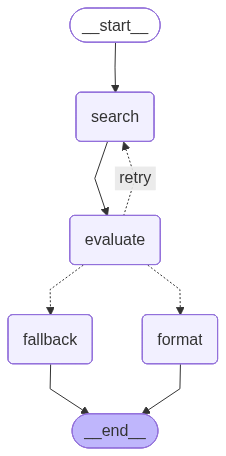

In [27]:
# Visualize the loop
try:
    display(Image(retry_app.get_graph().draw_mermaid_png()))
except:
    print("Graph structure (with loop):")
    print("START -> search -> evaluate -> [conditional]")
    print("  -> format -> END")
    print("  -> search (RETRY LOOP)")
    print("  -> fallback -> END")

In [30]:
# Run the retry graph
print("="*60)
print("RETRY GRAPH EXECUTION")
print("="*60)

result = retry_app.invoke({
    "query": "Python tutorials",
    "results": "",
    "attempts": 0,
    "max_attempts": 3,
    "success": False
})

print(f"\nFinal Result: {result['results']}")
print(f"Total Attempts: {result['attempts']}")

RETRY GRAPH EXECUTION
[SEARCH] Attempt 1/3
  -> Failed!
[EVALUATE] Success: False, Attempts: 1
[SEARCH] Attempt 2/3
  -> Failed!
[EVALUATE] Success: False, Attempts: 2
[SEARCH] Attempt 3/3
  -> Success!
[EVALUATE] Success: True, Attempts: 3
[FORMAT] Formatting results...

Final Result: Formatted: Results for 'Python tutorials': [data, data, data]
Total Attempts: 3


### Key Takeaway

With LangGraph, we have **explicit control** over:
- When to retry
- How many times
- What to do on failure

This was impossible with traditional LangChain agents!

---

# PART 3: Building Real Agent Workflows

---

## Section 3.1: Adding LLMs and Tools

Let's build a proper search agent with LangGraph:

In [32]:
import requests
from typing import List, Annotated
from operator import add

class SearchAgentState(TypedDict):
    question: str
    search_results: Annotated[List[str], add]
    summary: str
    final_answer: str

def plan_search(state: SearchAgentState) -> dict:
    """LLM decides what to search for."""
    print("[PLAN] LLM planning search...")
    prompt = f"""Given this question: "{state['question']}"
    What should we search for? Reply with just the search query."""
    
    response = llm.invoke(prompt)
    print(f"  -> Search query: {response.content}")
    SearchAgentState['search_results']: {response.content}
    return {}  # We'll use the original question for simplicity

def execute_search(state: SearchAgentState) -> dict:
    """Execute the actual search (simulated)."""
    print("[SEARCH] Executing search...")
    # Simulate search results
    results = [
        f"Result 1: Information about {state['question'][:20]}...",
        f"Result 2: More details on the topic...",
        f"Result 3: Expert opinions and analysis..."
    ]

    
    return {"search_results": results}

def summarize_results(state: SearchAgentState) -> dict:
    """LLM summarizes the search results."""
    print("[SUMMARIZE] LLM summarizing results...")
    results_text = "\n".join(state["search_results"])
    prompt = f"""Summarize these search results in 2-3 sentences:
    {results_text}"""
    
    response = llm.invoke(prompt)
    return {"summary": response.content}

def generate_answer(state: SearchAgentState) -> dict:
    """Generate final answer based on summary."""
    print("[ANSWER] Generating final answer...")
    prompt = f"""Based on this summary: "{state['summary']}"
    
    Answer the original question: "{state['question']}"
    
    Provide a clear, helpful answer."""
    
    response = llm.invoke(prompt)
    return {"final_answer": response.content}

print("Search agent nodes defined!")

Search agent nodes defined!


In [33]:
# Build the search agent graph

search_agent = StateGraph(SearchAgentState)

# Add nodes in order
search_agent.add_node("plan", plan_search)
search_agent.add_node("search", execute_search)
search_agent.add_node("summarize", summarize_results)
search_agent.add_node("answer", generate_answer)

# Linear flow for this example
search_agent.add_edge(START, "plan")
search_agent.add_edge("plan", "search")
search_agent.add_edge("search", "summarize")
search_agent.add_edge("summarize", "answer")
search_agent.add_edge("answer", END)

search_app = search_agent.compile()

print("Search agent compiled!")
print("Flow: plan -> search -> summarize -> answer")

Search agent compiled!
Flow: plan -> search -> summarize -> answer


In [34]:
# Run the search agent
print("="*60)
print("SEARCH AGENT EXECUTION")
print("="*60)

result = search_app.invoke({
    "question": "What are the best practices for building AI agents?",
    "search_results": [],
    "summary": "",
    "final_answer": ""
})

print("\n" + "="*60)
print("FINAL ANSWER:")
print("="*60)
print(result["final_answer"])

SEARCH AGENT EXECUTION
[PLAN] LLM planning search...
  -> Search query: "best practices for building AI agents"
[SEARCH] Executing search...
[SUMMARIZE] LLM summarizing results...
[ANSWER] Generating final answer...

FINAL ANSWER:
Building AI agents involves several best practices that can enhance their effectiveness and reliability. Here are some key recommendations:

1. **Define Clear Objectives**: Establish specific goals for what the AI agent should achieve. This includes understanding the problem it aims to solve and the desired outcomes.

2. **Data Quality and Quantity**: Ensure that the data used for training the AI agent is of high quality, relevant, and diverse. A large and well-curated dataset can significantly improve the agent's performance.

3. **Choose the Right Algorithms**: Select appropriate machine learning algorithms based on the nature of the task (e.g., supervised, unsupervised, reinforcement learning). Experiment with different models to find the best fit.

4. **I

## Section 3.2: Human-in-the-Loop

One of LangGraph's killer features: pausing for human approval!

In [32]:
from langgraph.checkpoint.memory import MemorySaver

class ApprovalState(TypedDict):
    task: str
    proposed_action: str
    approved: bool
    result: str

def propose_action(state: ApprovalState) -> dict:
    """LLM proposes an action."""
    print(f"[PROPOSE] Task: {state['task']}")
    prompt = f"""Given this task: "{state['task']}"
    What action would you propose? Be specific."""
    
    response = llm.invoke(prompt)
    print(f"  -> Proposed: {response.content[:100]}...")
    return {"proposed_action": response.content}

def execute_action(state: ApprovalState) -> dict:
    """Execute the approved action."""
    print("[EXECUTE] Running approved action...")
    return {"result": f"Executed: {state['proposed_action'][:50]}..."}

def reject_action(state: ApprovalState) -> dict:
    """Handle rejected action."""
    print("[REJECT] Action was rejected.")
    return {"result": "Action cancelled by human."}

print("Human-in-the-loop nodes defined!")

Human-in-the-loop nodes defined!


In [33]:
def check_approval(state: ApprovalState) -> str:
    """Route based on approval status."""
    if state.get("approved", False):
        return "execute"
    else:
        return "reject"

# Build graph with interrupt
approval_graph = StateGraph(ApprovalState)

approval_graph.add_node("propose", propose_action)
approval_graph.add_node("execute", execute_action)
approval_graph.add_node("reject", reject_action)

approval_graph.add_edge(START, "propose")

# After propose, we'll interrupt for human input
approval_graph.add_conditional_edges(
    "propose",
    check_approval,
    {"execute": "execute", "reject": "reject"}
)

approval_graph.add_edge("execute", END)
approval_graph.add_edge("reject", END)

# Compile with checkpointer (required for interrupts)
memory = MemorySaver()
approval_app = approval_graph.compile(
    checkpointer=memory,
    interrupt_after=["propose"]  # Interrupt after proposal!
)

print("Human-in-the-loop graph compiled!")
print("Will pause after 'propose' for human approval.")

Human-in-the-loop graph compiled!
Will pause after 'propose' for human approval.


In [37]:
# Run until interrupt
print("="*60)
print("PHASE 1: Get proposal (will pause for approval)")
print("="*60)

config = {"configurable": {"thread_id": "approval-1"}}

# First invoke - will stop after propose
result = approval_app.invoke(
    {
        "task": "Send an email to the team about the project update",
        "proposed_action": "",
        "approved": False,
        "result": ""
    },
    config
)

print(f"\nProposed Action: {result['proposed_action'][:200]}...")
print("\n>>> PAUSED - Waiting for human approval <<<")

PHASE 1: Get proposal (will pause for approval)
[PROPOSE] Task: Send an email to the team about the project update
  -> Proposed: To complete the task of sending an email to the team about the project update, I would propose the f...

Proposed Action: To complete the task of sending an email to the team about the project update, I would propose the following specific actions:

1. **Draft the Email:**
   - **Subject Line:** "Project Update - [Projec...

>>> PAUSED - Waiting for human approval <<<


In [38]:
# Simulate human approval
print("="*60)
print("PHASE 2: Human approves, continue execution")
print("="*60)

# Update state with approval and continue
approval_app.update_state(config, {"approved": False})

# Resume execution
final_result = approval_app.invoke(None, config)

print(f"\nFinal Result: {final_result['result']}")

PHASE 2: Human approves, continue execution
[REJECT] Action was rejected.

Final Result: Action cancelled by human.


## Section 3.3: Memory in Graphs

LangGraph supports both short-term (conversation) and long-term (persistent) memory:

In [30]:
from langchain_core.messages import HumanMessage, AIMessage, BaseMessage

class ChatState(TypedDict):
    messages: Annotated[List[BaseMessage], add]  # Conversation history
    summary: str  # Long-term memory summary

def chat_node(state: ChatState) -> dict:
    """Process chat with memory context."""
    messages = state["messages"]
    summary = state.get("summary", "")
    
    # Build context from summary + recent messages
    context = f"Previous conversation summary: {summary}\n\n" if summary else ""
    
    # Get response from LLM
    response = llm.invoke(messages)
    
    return {"messages": [response]}

def maybe_summarize(state: ChatState) -> dict:
    """Summarize conversation if too long."""
    messages = state["messages"]
    
    if len(messages) > 6:  # Threshold for summarization
        print("[SUMMARIZE] Conversation getting long, summarizing...")
        prompt = "Summarize the key points from this conversation briefly."
        summary_response = llm.invoke([
            HumanMessage(content=str(messages)),
            HumanMessage(content=prompt)
        ])
        return {"summary": summary_response.content}
    
    return {}

print("Chat nodes with memory defined!")

Chat nodes with memory defined!


In [31]:
# Build chat graph
chat_graph = StateGraph(ChatState)

chat_graph.add_node("chat", chat_node)
chat_graph.add_node("summarize", maybe_summarize)

chat_graph.add_edge(START, "chat")
chat_graph.add_edge("chat", "summarize")
chat_graph.add_edge("summarize", END)

# Compile with checkpointer for persistence
chat_memory = MemorySaver()
chat_app = chat_graph.compile(checkpointer=chat_memory)

print("Chat graph with memory compiled!")

Chat graph with memory compiled!


In [32]:
# Multi-turn conversation
chat_config = {"configurable": {"thread_id": "chat-1"}}

# Turn 1
print("Turn 1:")
result1 = chat_app.invoke(
    {"messages": [HumanMessage(content="Hi! My name is Alice.")], "summary": ""},
    chat_config
)
print(f"User: Hi! My name is Alice.")
print(f"AI: {result1['messages'][-1].content}")

# Turn 2 - Memory persists!
print("\nTurn 2:")
result2 = chat_app.invoke(
    {"messages": [HumanMessage(content="What's my name?")], "summary": ""},
    chat_config
)
print(f"User: What's my name?")
print(f"AI: {result2['messages'][-1].content}")

Turn 1:
User: Hi! My name is Alice.
AI: Hi Alice! How can I assist you today?

Turn 2:
User: What's my name?
AI: Your name is Alice! How can I help you today?


---

# PART 4: LangGraph vs LangChain Agents Comparison

---

## Side-by-Side Comparison

| Feature | LangChain Agents | LangGraph |
|---------|-----------------|----------|
| **Control Flow** | LLM decides | You define the graph |
| **State Management** | Scratchpad (hidden) | Explicit typed state |
| **Branching** | Implicit in LLM reasoning | Explicit conditional edges |
| **Loops/Retries** | Hard to control | Explicit cycles in graph |
| **Human Approval** | Not built-in | `interrupt_after` support |
| **Debugging** | `verbose=True`, hope for best | State inspection, checkpoints |
| **Predictability** | Low (LLM decides) | High (graph structure) |
| **Error Handling** | `handle_parsing_errors` | Explicit error nodes |
| **Best For** | Simple tool-calling | Complex, production workflows |

## When to Use Which?

### Use LangChain Agents when:
- Simple tool-calling tasks
- Prototyping quickly
- The LLM should decide everything
- You trust the model's judgment

### Use LangGraph when:
- Production applications
- Complex workflows with branching
- Need retry/fallback logic
- Human approval required
- Debugging and observability matter
- Predictable behavior is critical

In [33]:
# Final Example: The same task, two approaches

# Task: Search for info, validate, summarize

print("="*60)
print("LANGCHAIN AGENT APPROACH")
print("="*60)
print("""
# Define tools
@tool
def search(query): ...
@tool  
def validate(data): ...

# Create agent - LLM decides what to do
agent = create_tool_calling_agent(llm, [search, validate], prompt)
executor = AgentExecutor(agent=agent, tools=tools)

# Run - hope for the best!
result = executor.invoke({"input": "Find Python tutorials"})

# Problems:
# - LLM might skip validation
# - No control over retry logic
# - Can't pause for approval
""")

print("\n" + "="*60)
print("LANGGRAPH APPROACH")
print("="*60)
print("""
# Define state
class State(TypedDict):
    query: str
    results: list
    is_valid: bool
    summary: str

# Define nodes
def search_node(state): ...
def validate_node(state): ...
def summarize_node(state): ...

# Build graph - YOU control the flow
graph = StateGraph(State)
graph.add_edge(START, "search")
graph.add_edge("search", "validate")
graph.add_conditional_edges("validate", route, {...})
...

# Benefits:
# - Guaranteed to validate
# - Explicit retry logic
# - Can interrupt for approval
# - Full state visibility
""")

LANGCHAIN AGENT APPROACH

# Define tools
@tool
def search(query): ...
@tool  
def validate(data): ...

# Create agent - LLM decides what to do
agent = create_tool_calling_agent(llm, [search, validate], prompt)
executor = AgentExecutor(agent=agent, tools=tools)

# Run - hope for the best!
result = executor.invoke({"input": "Find Python tutorials"})

# Problems:
# - LLM might skip validation
# - No control over retry logic
# - Can't pause for approval


LANGGRAPH APPROACH

# Define state
class State(TypedDict):
    query: str
    results: list
    is_valid: bool
    summary: str

# Define nodes
def search_node(state): ...
def validate_node(state): ...
def summarize_node(state): ...

# Build graph - YOU control the flow
graph = StateGraph(State)
graph.add_edge(START, "search")
graph.add_edge("search", "validate")
graph.add_conditional_edges("validate", route, {...})
...

# Benefits:
# - Guaranteed to validate
# - Explicit retry logic
# - Can interrupt for approval
# - Full state visibilit

## Summary: What You've Learned

### Part 1 - Why LangGraph:
- Traditional agents have unpredictable behavior
- LangGraph provides explicit control via graphs
- Nodes = steps, Edges = transitions, State = memory

### Part 2 - Control Flow:
- Typed state objects with reducers
- Conditional edges for branching
- Cycles for retry logic

### Part 3 - Real Workflows:
- Combining LLM and tool nodes
- Human-in-the-loop with interrupts
- Short-term and long-term memory

### Part 4 - Comparison:
- LangChain Agents: Simple, LLM-driven
- LangGraph: Complex, developer-controlled

### Key Mental Model:

```
"Think in GRAPHS, not LOOPS"

- Define your NODES (what happens at each step)
- Define your EDGES (how steps connect)
- Define your STATE (what data flows through)
- Let the GRAPH handle execution
```